# Simple ROC-AUC and Targeted Confusion Matrix

This notebook teaches only this flow:

```text
model → probabilities → ROC-AUC → threshold → confusion matrix
```

- **ROC-AUC** evaluates probability ranking across all thresholds.
- **Confusion matrix** evaluates predictions at one selected threshold.

In [12]:
from pathlib import Path 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
)

path=Path("../data/fraud_classification_1.csv")

## 1. Load data

In [14]:
df = pd.read_csv(path)
df.head()

,transaction_id,customer_age,account_age_days,transaction_amount,hour_of_day,day_of_week,merchant_category,transaction_type,channel,international,country_match,device_trusted,previous_failed_attempts,transactions_last_24h,avg_amount_30d,amount_to_avg_ratio,distance_from_home_km,card_present,is_fraud
0,TXN000001,43,565,8.75,23,Saturday,grocery,purchase,mobile_app,0,1,0,1,9,8.00,1.0938,29.40,0,0
1,TXN000002,25,1085,15.65,7,Monday,electronics,transfer,web,0,1,1,0,2,62.96,0.2485,35.13,0,0
2,TXN000003,49,748,21.09,8,Thursday,healthcare,purchase,mobile_app,0,1,1,0,7,20.65,1.0216,14.79,0,0
3,TXN000004,51,1723,8.20,0,Friday,grocery,bill_payment,atm,0,1,1,0,3,15.28,0.5370,46.85,1,0
4,TXN000005,18,265,30.88,5,Saturday,electronics,transfer,pos,0,1,1,1,3,37.13,0.8318,24.01,1,0


## 2. Prepare X and y

In [15]:
X = df.drop(columns=["transaction_id", "is_fraud"])
y = df["is_fraud"]

# Convert text columns into numbers.
X = pd.get_dummies(X, drop_first=True)

print("Features:", X.shape[1])
print("Fraud cases:", y.sum())

Features: 32
Fraud cases: 134


## 3. Train-test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

## 4. Train one simple model

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## 5. Get probabilities

This line gives the probability of class `1`, meaning fraud.

In [18]:
y_probability = model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "actual": y_test.to_numpy(),
    "fraud_probability": y_probability,
}).head(10)

,actual,fraud_probability
0,0,0.105
1,1,0.250
2,0,0.030
3,0,0.055
4,0,0.075
5,1,0.095
6,0,0.005
7,0,0.340
8,0,0.070
9,0,0.040


## 6. Calculate ROC-AUC

In [21]:
print("y probablities")
print(y_probability)
auc = roc_auc_score(y_test, y_probability)
print("ROC-AUC:", round(auc, 4))

y probablities
[0.105 0.25  0.03  0.055 0.075 0.095 0.005 0.34  0.07  0.04  0.    0.275
 0.025 0.15  0.01  0.09  0.01  0.005 0.015 0.1   0.06  0.05  0.02  0.05
 0.015 0.055 0.145 0.06  0.    0.02  0.055 0.065 0.07  0.04  0.035 0.065
 0.105 0.18  0.005 0.015 0.04  0.03  0.215 0.015 0.035 0.07  0.025 0.02
 0.025 0.03  0.025 0.025 0.02  0.14  0.005 0.095 0.09  0.025 0.035 0.04
 0.03  0.045 0.335 0.025 0.015 0.05  0.07  0.09  0.    0.035 0.065 0.29
 0.075 0.055 0.065 0.06  0.105 0.055 0.03  0.015 0.02  0.055 0.07  0.045
 0.075 0.08  0.015 0.06  0.    0.005 0.095 0.055 0.025 0.06  0.125 0.195
 0.025 0.155 0.09  0.02  0.035 0.01  0.    0.02  0.035 0.11  0.045 0.07
 0.28  0.095 0.04  0.02  0.08  0.035 0.155 0.025 0.025 0.13  0.09  0.06
 0.01  0.035 0.365 0.095 0.015 0.325 0.065 0.03  0.015 0.03  0.01  0.05
 0.015 0.025 0.04  0.065 0.075 0.025 0.08  0.02  0.04  0.045 0.07  0.035
 0.145 0.125 0.065 0.005 0.365 0.1   0.06  0.035 0.005 0.085 0.195 0.09
 0.125 0.07  0.02  0.18  0.005 0.055 0.015 0

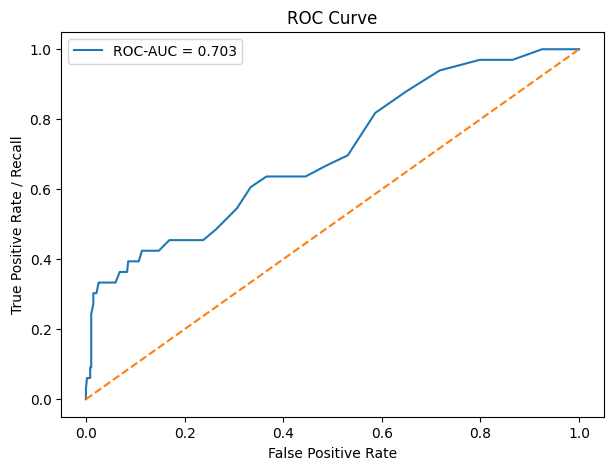

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_probability)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 7. Confusion matrix at threshold 0.50

A probability becomes a prediction using:

```python
prediction = probability >= threshold
```

In [ ]:
threshold = 0.50
y_pred_050 = (y_probability >= threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_050,
    values_format="d",
)
plt.title("Threshold = 0.50")
plt.show()

print("Precision:", round(precision_score(y_test, y_pred_050, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_050), 4))

## 8. Select a threshold for 80% recall

Among thresholds reaching at least `80%` recall, select the one with the lowest false-positive rate.

This uses the test data only for learning. In a real project, select the threshold on validation data.

In [ ]:
target_recall = 0.80

valid_indexes = np.where(tpr >= target_recall)[0]
best_index = valid_indexes[np.argmin(fpr[valid_indexes])]
best_threshold = thresholds[best_index]

print("Selected threshold:", round(best_threshold, 4))
print("Recall:", round(tpr[best_index], 4))
print("False positive rate:", round(fpr[best_index], 4))

## 9. Targeted confusion matrix

In [ ]:
y_pred_target = (y_probability >= best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_target,
    values_format="d",
)
plt.title(f"Targeted threshold = {best_threshold:.3f}")
plt.show()

print("Precision:", round(precision_score(y_test, y_pred_target, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_pred_target), 4))

## 10. Compare several thresholds

In [ ]:
results = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60]:
    prediction = (y_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, prediction).ravel()

    results.append({
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": precision_score(y_test, prediction, zero_division=0),
        "recall": recall_score(y_test, prediction),
    })

pd.DataFrame(results).round(4)

# Remember

```text
ROC-AUC = quality of probability ranking
threshold = decision boundary
confusion matrix = result after applying that threshold
```

Lowering the threshold usually increases recall but also increases false positives.